## Speed and Memory Test

### 1. Speed

This test uses pytest benchmark to test your algorithm.

```
run_benchmark(benchmark_filename, algorithm_name=['ssca', 'fam'], param_name='param')
```

You need to create a seperate python file for this. The example we use is ssca_fam_fastsc_speed_test.py. Use that as an example format or consult pytest benchmark [documentation](https://pytest-benchmark.readthedocs.io/en/latest/). 

The function shown above will return a panda dataframe of the result. We also include another function to plot the result for ease of use.

In [3]:
import numpy as np
import scf_test.tests as test

benchmark_name = "speed_test_files/scf_2d_fft.py" # file name here

df = test.run_benchmark(benchmark_name, algorithm_name=['scf_2d_fft'], param_name='Np') # Make sure the algorithm name match test_[algorithm name] in the other file

============================= test session starts =============================
platform win32 -- Python 3.13.5, pytest-8.3.4, pluggy-1.5.0
benchmark: 5.1.0 (defaults: timer=time.perf_counter disable_gc=True min_rounds=50 min_time=0.000005 max_time=1.0 calibration_precision=10 warmup=False warmup_iterations=100000)
rootdir: C:\Users\vngu6249\OneDrive - The University of Sydney (Staff)\Documents\Spectral_Correlation_Estimation_Test
configfile: pyproject.toml
plugins: anyio-4.7.0, benchmark-5.1.0
collected 7 items

speed_test_files\scf_2d_fft.py .......                                   [100%]


-------------------------------------------------------------------------------- benchmark: 7 tests -------------------------------------------------------------------------------
Name (time in s)            Min               Max              Mean            StdDev            Median               IQR            Outliers     OPS            Rounds  Iterations
---------------------------------------

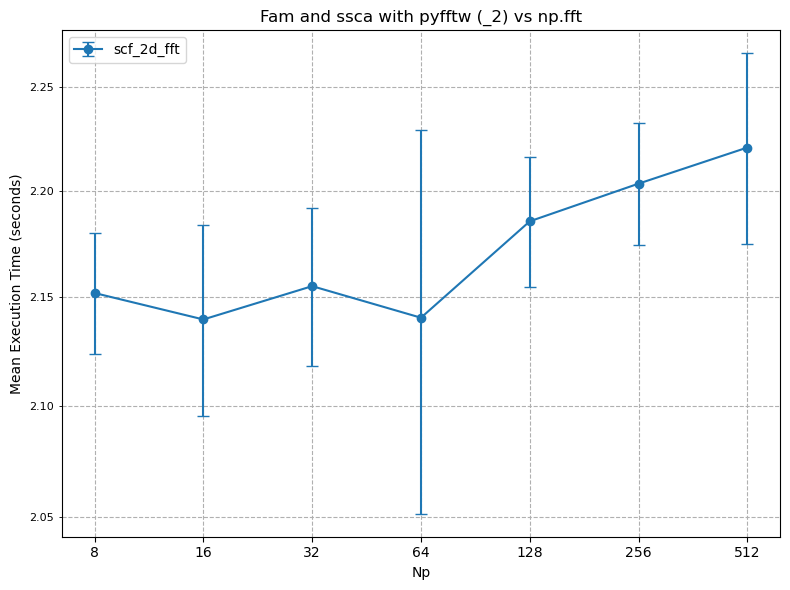

In [4]:
test.plot_benchmark(df, param_name='Np', title="Fam and ssca with pyfftw (_2) vs np.fft", xlabel="Np", 
                   log_x=True, log_y=True, figsize=(8,6), save_path=None)

df.to_csv('data/csv/scf_2d_fft.csv')

In [22]:
df.head()

,name,group,min,max,mean,stddev,rounds,median,iqr,q1,...,stddev_outliers,outliers,ld15iqr,hd15iqr,ops,total,data,iterations,algorithm,Np
0,test_scf_2d_fft[8],None,2.116862,2.308740,2.211482,0.040300,50,2.209237,0.054291,2.181862,...,13,13;0,2.116862,2.308740,0.452185,110.574114,"[2.2663589000003412, 2.287688700002036, 2.1915...",1,scf_2d_fft,8
1,test_scf_2d_fft[16],None,2.024669,2.316691,2.209733,0.042764,50,2.210194,0.030576,2.198216,...,5,5;4,2.162878,2.315624,0.452543,110.486649,"[2.205314200007706, 2.1937588000000687, 2.2430...",1,scf_2d_fft,16
2,test_scf_2d_fft[32],None,2.132798,2.316419,2.224602,0.032541,50,2.224500,0.025132,2.212949,...,11,11;6,2.180928,2.281965,0.449519,111.230121,"[2.1809276999993017, 2.132798399994499, 2.1981...",1,scf_2d_fft,32
3,test_scf_2d_fft[64],None,2.108437,2.287387,2.198069,0.041619,50,2.205482,0.049152,2.173557,...,18,18;0,2.108437,2.287387,0.454945,109.903451,"[2.2385441999940667, 2.242386700003408, 2.2873...",1,scf_2d_fft,64
4,test_scf_2d_fft[128],None,2.050130,2.274062,2.195935,0.042199,50,2.203056,0.044557,2.176564,...,9,9;2,2.121822,2.274062,0.455387,109.796761,"[2.202193699995405, 2.181551200003014, 2.16096...",1,scf_2d_fft,128


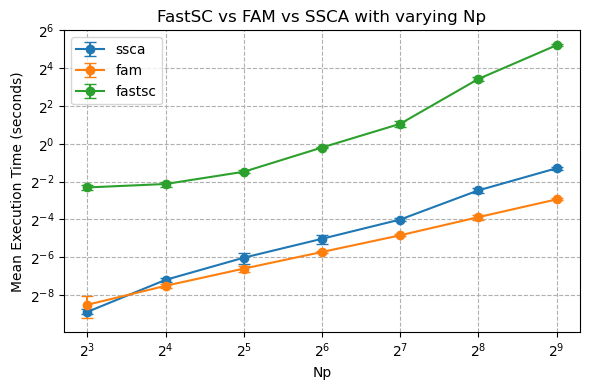

In [2]:
test.plot_benchmark(df, param_name='Np', title="FastSC vs FAM vs SSCA with varying Np", xlabel="Np", 
                   log_x=True, log_y=True, figsize=(6, 4), save_path=None)

There are also other example speed test files in speed_test_files folder that you can test out. The usage is the same.

### 2. Memory 

```
memory_test(func_lambda, name="algorithm", Np=8, L=2, max_log_2=18, no_of_run=10, fam=True, plot=True)
```

The memory test function is simplier and return the peak usage as we vary N and fix Np. It also returns the standard deviation of the memory used.

In [1]:
from scf_test.algorithm import fam, ssca, Fast_SC, scf_2d_fft_wrapper
import numpy as np
import scf_test.tests as test

In [5]:
def fast_sc_wrapper(signal, Np=64, conjugate=False, coherence=False):
    if coherence:
        opt = {"abs": 0, "calib": 1, "coh": 1}
    else:
        opt = {"abs": 0, "calib": 1, "coh": 0}

    Sx, alpha, f, _, _, _ = Fast_SC(signal, Nw=Np, alpha_max=0.5, Fs=1, opt=opt)

    return np.abs(Sx), f, alpha

In [6]:
fam_peak_usage_8, fam_standard_deviation_8, length = test.memory_test(fam, name="FAM", fam=True,plot=False)
fam_peak_usage_32, fam_standard_deviation_32, length = test.memory_test(fam, name="FAM", fam=True, Np=32, L=8, plot=False)
fam_peak_usage_128, fam_standard_deviation_128, length = test.memory_test(fam, name="FAM", fam=True, Np=128, L=32, plot=False)

ssca_peak_usage_8, ssca_standard_deviation_8, length = test.memory_test(ssca, name="SSCA", plot=False)
ssca_peak_usage_32, ssca_standard_deviation_32, length = test.memory_test(ssca, name="SSCA", Np=32, plot=False)
ssca_peak_usage_128, ssca_standard_deviation_128, length = test.memory_test(ssca, name="SSCA", Np=128, plot=False)

fastsc_peak_usage_8, fastsc_standard_deviation_8, length = test.memory_test(fast_sc_wrapper, name="FastSC", plot=False)
fastsc_peak_usage_32, fastsc_standard_deviation_32, length = test.memory_test(fast_sc_wrapper, name="FastSC", Np=32, plot=False)
fastsc_peak_usage_128, fastsc_standard_deviation_128, length = test.memory_test(fast_sc_wrapper, name="FastSC", Np=128, plot=False)

scf_2d_fft_peak_usage_8, scf_2d_fft_standard_deviation_8, length = test.memory_test(scf_2d_fft_wrapper, name="SC2DFFT", plot=False)
scf_2d_fft_peak_usage_32, scf_2d_fft_standard_deviation_32, length = test.memory_test(scf_2d_fft_wrapper, name="SC2DFFT", Np=32, plot=False)
scf_2d_fft_peak_usage_128, scf_2d_fft_standard_deviation_128, length = test.memory_test(scf_2d_fft_wrapper, name="SC2DFFT", Np=128, plot=False)

np.save('data/fam_peak_memory', np.concatenate(fam_peak_usage_8, fam_peak_usage_32, fam_peak_usage_128))
np.save('data/ssca_peak_memory', np.concatenate(ssca_peak_usage_8, ssca_peak_usage_32, ssca_peak_usage_128))
np.save('data/fastsc_peak_memory', np.concatenate(fastsc_peak_usage_8, fastsc_peak_usage_32, fastsc_peak_usage_128))
np.save('data/scf_2d_fft_peak_memory', np.concatenate(scf_2d_fft_peak_usage_8, scf_2d_fft_peak_usage_32, scf_2d_fft_peak_usage_128))

MemoryError: Unable to allocate 64.0 GiB for an array with shape (65536, 65536) and data type complex128

We don't have a function for plotting but it should be simple to do with matplotlib

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(3.5, 5), sharex=True)
plt.suptitle('SSCA and FAM Memory Usage vs. Signal Length', y=0.995)
fig.text(0.5, 0.01, 'Signal Length (samples)', ha='center')
fig.text(0.01, 0.5, 'Peak Memory Usage (MB)', va='center', rotation='vertical')

axes[0].errorbar(length, ssca_peak_usage_8, yerr=ssca_standard_deviation_8, marker='o', capsize=4, label="SSCA, Np=8")
axes[0].errorbar(length, fam_peak_usage_8, yerr=fam_standard_deviation_8, marker='o', capsize=4, label="FAM, Np=8")
axes[0].errorbar(length, fastsc_peak_usage_8, yerr=fastsc_standard_deviation_8, marker='o', capsize=4, label="FastSC, Nw=8")
axes[0].errorbar(length, scf_2d_fft_peak_usage_8, yerr=scf_2d_fft_standard_deviation_8, marker='o', capsize=4, label="FastSC, Nw=8")
axes[0].set_xscale('log', base=2)
axes[0].legend()
axes[0].grid(True, alpha=0.3, linestyle='--')
axes[0].set_yticks([0, 25, 50, 75, 100, 125])

axes[1].errorbar(length, ssca_peak_usage_32, yerr=ssca_standard_deviation_32, marker='o', capsize=4, label="SSCA, Np=32")
axes[1].errorbar(length, fam_peak_usage_32, yerr=fam_standard_deviation_32, marker='o', capsize=4, label="FAM, Np=32")
axes[1].errorbar(length, fastsc_peak_usage_32, yerr=fastsc_standard_deviation_32, marker='o', capsize=4, label="FastSC, Nw=32")
axes[0].errorbar(length, scf_2d_fft_peak_usage_32, yerr=scf_2d_fft_standard_deviation_32, marker='o', capsize=4, label="SC2DFFT, Nw=32")
axes[1].set_xscale('log', base=2)
axes[1].legend()
axes[1].grid(True, alpha=0.3, linestyle='--')
axes[1].set_yticks([0, 100, 200, 300, 400])

axes[2].errorbar(length, ssca_peak_usage_128, yerr=ssca_standard_deviation_128, marker='o', capsize=4, label="SSCA, Np=128")
axes[2].errorbar(length, fam_peak_usage_128, yerr=fam_standard_deviation_128, marker='o', capsize=4, label="FAM, Np=128")
axes[2].errorbar(length, fastsc_peak_usage_128, yerr=fastsc_standard_deviation_128, marker='o', capsize=4, label="FastSC, Nw=128")
axes[0].errorbar(length, scf_2d_fft_peak_usage_128, yerr=scf_2d_fft_standard_deviation_128, marker='o', capsize=4, label="SC2DFFT, Nw=128")
axes[2].set_xscale('log', base=2)
axes[2].set_xlim(length[0] * 0.9, length[-1] * 1.1)
axes[2].legend()
axes[2].grid(True, alpha=0.3, linestyle='--')
axes[2].set_yticks([0, 250, 500, 750, 1000, 1250])

plt.tight_layout()
plt.savefig("fig/memory_test.png")
plt.show()